# Ekstraksi EMNIST ByClass ke Gambo_Balanced

Notebook ini mengekstrak gambar alfabet dari `emnist-byclass-train.csv` lalu menyimpannya ke struktur dataset:

```
Dataset/Gambo_Balanced/
├── Train/Normal/
├── Validation/Normal/
└── Test/Normal/
```

dengan aturan berikut:

* **Hanya alfabet** (`A-Z`, `a-z`) — digit `0-9` dibuang
* **Split per huruf** untuk mencegah data leakage antar subset
* **3-way split:** Train / Validation / Test
* **Penamaan file mengikuti format dataset baru**
* **Index file melanjutkan file yang sudah ada**
* **Seed acak tetap** (`42`) agar hasil reproducible
* **Orientasi EMNIST diperbaiki** menggunakan transpose (`.T`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import re
import random
from collections import defaultdict

# =========================================================
# Reproducibility
# =========================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f'Random seed set to: {SEED}')

Random seed set to: 42


## 1. Load Mapping Label (ASCII)

Load file mapping EMNIST untuk menghubungkan:

- `label integer` → `ASCII code`
- `ASCII code` → `karakter alfabet`

Kemudian dilakukan filtering agar hanya karakter alfabet (`A-Z`, `a-z`) yang diproses.

Digit (`0-9`) akan dibuang karena tidak digunakan pada dataset `Gambo_Balanced`.

In [2]:
# =========================================================
# Load EMNIST Mapping
# =========================================================
mapping_path = os.path.join(
    'Dataset',
    'emnist-byclass-mapping.txt'
)

df_mapping = pd.read_csv(
    mapping_path,
    sep=' ',
    header=None,
    names=['label', 'ascii_code']
)

# =========================================================
# Mapping:
# label_id -> ascii_code
# =========================================================
label_to_ascii = dict(
    zip(
        df_mapping['label'],
        df_mapping['ascii_code']
    )
)

# =========================================================
# Mapping:
# label_id -> character
# =========================================================
label_to_char = {
    label_id: chr(ascii_code)
    for label_id, ascii_code
    in label_to_ascii.items()
}

# =========================================================
# Filter:
# Hanya alfabet (A-Z, a-z)
# =========================================================
alpha_labels = {
    label_id: char
    for label_id, char
    in label_to_char.items()
    if char.isalpha()
}

# =========================================================
# Statistik Mapping
# =========================================================
total_classes = len(label_to_char)
total_alpha = len(alpha_labels)
total_digits = total_classes - total_alpha

print('=' * 60)
print('EMNIST LABEL MAPPING')
print('=' * 60)

print(f'Total kelas EMNIST : {total_classes}')
print(f'Kelas alfabet      : {total_alpha}')
print(f'Kelas digit dibuang: {total_digits}')

# =========================================================
# Preview Mapping
# =========================================================
print('\nContoh mapping alfabet:')

preview_items = list(alpha_labels.items())[:10]

for label_id, char in preview_items:
    ascii_code = label_to_ascii[label_id]

    print(
        f'  Label {label_id:>2} '
        f'-> ASCII {ascii_code:>3} '
        f'-> "{char}"'
    )

EMNIST LABEL MAPPING
Total kelas EMNIST : 62
Kelas alfabet      : 52
Kelas digit dibuang: 10

Contoh mapping alfabet:
  Label 10 -> ASCII  65 -> "A"
  Label 11 -> ASCII  66 -> "B"
  Label 12 -> ASCII  67 -> "C"
  Label 13 -> ASCII  68 -> "D"
  Label 14 -> ASCII  69 -> "E"
  Label 15 -> ASCII  70 -> "F"
  Label 16 -> ASCII  71 -> "G"
  Label 17 -> ASCII  72 -> "H"
  Label 18 -> ASCII  73 -> "I"
  Label 19 -> ASCII  74 -> "J"


## 2. Load CSV EMNIST ByClass

Load dataset `emnist-byclass-train.csv` yang berisi:

- kolom pertama → label karakter
- 784 kolom berikutnya → piksel gambar (`28×28`)

Setiap baris merepresentasikan satu gambar handwritten character.

Dataset dibaca menggunakan `dtype=np.uint8` untuk menghemat penggunaan RAM karena nilai piksel hanya berada pada rentang `0-255`.

Setelah data dipisahkan menjadi:
- `labels`
- `pixels`

DataFrame utama akan dihapus dari memori untuk efisiensi.

In [3]:
# =========================================================
# Load EMNIST ByClass CSV
# =========================================================
csv_path = os.path.join(
    'Dataset',
    'emnist-byclass-train.csv'
)

print('=' * 60)
print('LOADING EMNIST CSV')
print('=' * 60)

print(f'Loading file:')
print(f'  {csv_path}')

# =========================================================
# Read CSV
# =========================================================
df = pd.read_csv(
    csv_path,
    header=None,
    dtype=np.uint8
)

# =========================================================
# Dataset Shape
# =========================================================
rows, cols = df.shape

print('\nDataset loaded successfully.')
print(f'Total samples : {rows:,}')
print(f'Total columns : {cols}')

# =========================================================
# Column Structure
# =========================================================
print('\nColumn structure:')
print('  Column 0       -> Label')
print('  Column 1-784   -> Pixel values')

# =========================================================
# Split:
# labels & pixels
# =========================================================
labels = df.iloc[:, 0].values

pixels = df.iloc[:, 1:].values

print('\nArray shapes:')
print(f'  labels : {labels.shape}')
print(f'  pixels : {pixels.shape}')

# =========================================================
# Pixel Validation
# =========================================================
print('\nPixel statistics:')
print(f'  Min pixel value : {pixels.min()}')
print(f'  Max pixel value : {pixels.max()}')

# =========================================================
# Memory Cleanup
# =========================================================
del df

print('\nDataFrame deleted from RAM.')

LOADING EMNIST CSV
Loading file:
  Dataset\emnist-byclass-train.csv

Dataset loaded successfully.
Total samples : 697,932
Total columns : 785

Column structure:
  Column 0       -> Label
  Column 1-784   -> Pixel values

Array shapes:
  labels : (697932,)
  pixels : (697932, 784)

Pixel statistics:
  Min pixel value : 0
  Max pixel value : 255

DataFrame deleted from RAM.


## 3. Filter Hanya Alfabet (Buang Digit 0-9)

Dataset EMNIST ByClass mengandung:
- digit (`0-9`)
- huruf uppercase (`A-Z`)
- huruf lowercase (`a-z`)

Pada pipeline ini hanya karakter alfabet yang digunakan untuk kelas `Normal`.

Langkah ini akan:

1. Memfilter hanya label alfabet
2. Menghapus seluruh digit
3. Mengurangi ukuran dataset
4. Menyiapkan data untuk proses split Train / Validation / Test

Setelah filtering selesai:
- array label digit akan dibuang dari memori
- hanya data alfabet yang dipertahankan

In [4]:
# =========================================================
# Filter:
# Hanya alfabet (A-Z, a-z)
# =========================================================

print('=' * 60)
print('FILTER ALFABET')
print('=' * 60)

# Set label alfabet
alpha_label_set = set(alpha_labels.keys())

# =========================================================
# Mask:
# True jika label termasuk alfabet
# =========================================================
mask = np.isin(
    labels,
    list(alpha_label_set)
)

# =========================================================
# Filter labels & pixels
# =========================================================
alpha_labels_arr = labels[mask]

alpha_pixels = pixels[mask]

# =========================================================
# Statistik Filtering
# =========================================================
total_before = len(labels)
total_after = len(alpha_labels_arr)
total_removed = total_before - total_after

print(f'Total sample sebelum filter : {total_before:,}')
print(f'Total sample alfabet        : {total_after:,}')
print(f'Total digit dibuang         : {total_removed:,}')

# =========================================================
# Persentase alfabet
# =========================================================
alpha_ratio = (
    total_after / total_before
) * 100

print(f'\nPersentase alfabet retained: {alpha_ratio:.2f}%')

# =========================================================
# Distribusi per karakter
# =========================================================
print('\nContoh distribusi karakter:')

unique_alpha, counts_alpha = np.unique(
    alpha_labels_arr,
    return_counts=True
)

preview_limit = 10

for label_id, count in zip(
    unique_alpha[:preview_limit],
    counts_alpha[:preview_limit]
):
    char = label_to_char[int(label_id)]

    print(
        f'  "{char}" '
        f'(Label {label_id:>2}) '
        f': {count:,} gambar'
    )

# =========================================================
# Memory Cleanup
# =========================================================
del labels
del pixels
del mask

print('\nOriginal arrays deleted from RAM.')

FILTER ALFABET
Total sample sebelum filter : 697,932
Total sample alfabet        : 352,897
Total digit dibuang         : 345,035

Persentase alfabet retained: 50.56%

Contoh distribusi karakter:
  "A" (Label 10) : 6,407 gambar
  "B" (Label 11) : 3,878 gambar
  "C" (Label 12) : 10,094 gambar
  "D" (Label 13) : 4,562 gambar
  "E" (Label 14) : 4,934 gambar
  "F" (Label 15) : 9,182 gambar
  "G" (Label 16) : 2,517 gambar
  "H" (Label 17) : 3,152 gambar
  "I" (Label 18) : 11,946 gambar
  "J" (Label 19) : 3,762 gambar

Original arrays deleted from RAM.


## 4. Visualisasi Sample (Verifikasi Orientasi)

EMNIST ByClass menyimpan gambar dalam format flatten (`784 pixel`) sehingga perlu direkonstruksi kembali menjadi image 2D.

Tahap ini digunakan untuk:

- memverifikasi gambar berhasil direkonstruksi dengan benar
- memastikan orientasi karakter tidak terbalik
- melihat variasi handwriting alfabet
- melakukan sanity check sebelum proses export PNG

Catatan:
- Resolusi gambar tetap original EMNIST (`28×28`)
- Tidak dilakukan resize/interpolasi
- `.reshape(28,28)` hanya merekonstruksi bentuk asli gambar
- `.T` digunakan untuk memperbaiki orientasi EMNIST

VISUALISASI SAMPLE EMNIST


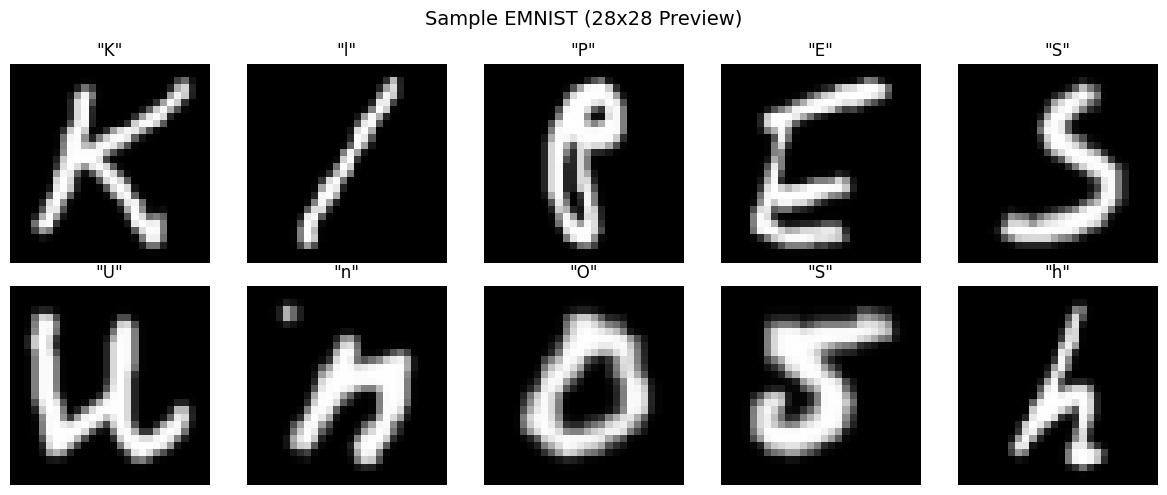

In [5]:
# =========================================================
# Visualisasi Sample EMNIST
# =========================================================

print('=' * 60)
print('VISUALISASI SAMPLE EMNIST')
print('=' * 60)

NUM_SAMPLES = 10

TARGET_SIZE = (28, 28)

# =========================================================
# Ambil sample acak
# =========================================================
sample_indices = np.random.choice(
    len(alpha_labels_arr),
    NUM_SAMPLES,
    replace=False
)

# =========================================================
# Setup figure
# =========================================================
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5)
)

fig.suptitle(
    'Sample EMNIST (28x28 Preview)',
    fontsize=14
)

# =========================================================
# Render image
# =========================================================
for i, ax in enumerate(axes.flatten()):

    idx = sample_indices[i]

    # =====================================================
    # Reconstruct image
    # =====================================================
    img = alpha_pixels[idx].reshape(28, 28)

    # =====================================================
    # Fix orientation
    # =====================================================
    img = img.T

    # =====================================================
    # Convert ke PIL
    # =====================================================
    img_pil = Image.fromarray(
        img,
        mode='L'
    )

    # =====================================================
    # Resize untuk CNN preview
    # =====================================================
    img_pil = img_pil.resize(
        TARGET_SIZE,
        Image.Resampling.LANCZOS
    )

    # =====================================================
    # Character label
    # =====================================================
    label_id = int(alpha_labels_arr[idx])

    char = label_to_char[label_id]

    # =====================================================
    # Show image
    # =====================================================
    ax.imshow(
        img_pil,
        cmap='gray'
    )

    ax.set_title(f'"{char}"')

    ax.axis('off')

# =========================================================
# Layout
# =========================================================
plt.tight_layout()

# =========================================================
# Show figure
# =========================================================
plt.show()

## 5. Rename Existing Normal Files (Migrasi Naming Lama)

Tahap ini digunakan untuk mengubah seluruh filename `Normal` lama ke format naming baru yang lebih aman dan konsisten.

Tujuan:

* membedakan huruf uppercase dan lowercase
* mencegah collision filename di Windows
* menyeragamkan naming dataset final
* mempersiapkan incremental indexing EMNIST berikutnya

Perubahan format:

```text id="jlwmz1"
Train_Normal_A-3.png
→
Train_Normal_Upper_A_00003.png
```

```text id="jlwmz2"
Train_Normal_a-17.png
→
Train_Normal_Lower_a_00017.png
```

Catatan:

* index lama tetap dipertahankan
* uppercase → `Upper`
* lowercase → `Lower`
* menggunakan zero-padding (`00001`)
* file non-matching akan dilewati otomatis


In [28]:
# =========================================================
# RENAME EXISTING NORMAL FILES
# OLD FORMAT -> NEW STANDARD FORMAT
# =========================================================

import os
import re

print('=' * 60)
print('RENAMING NORMAL FILES')
print('=' * 60)

# =========================================================
# Base path
# =========================================================
BASE = 'Dataset'

# =========================================================
# Splits
# =========================================================
SPLITS = [
    'Train',
    'Validation',
    'Test'
]

# =========================================================
# OLD FORMAT
#
# Train_Normal_A-3.png
# Validation_Normal_a-17.png
# =========================================================
OLD_PATTERN = re.compile(
    r'^(Train|Validation|Test)_Normal_([A-Za-z])-(\d+)\.png$'
)

# =========================================================
# Statistics
# =========================================================
total_renamed = 0

# =========================================================
# Process per split
# =========================================================
for split in SPLITS:

    print('\n' + '=' * 60)
    print(split.upper())
    print('=' * 60)

    normal_folder = os.path.join(
        BASE,
        'Gambo_Balanced',
        split,
        'Normal'
    )

    # =====================================================
    # Folder check
    # =====================================================
    if not os.path.exists(normal_folder):

        print('Folder not found.')

        continue

    files = sorted(
        os.listdir(normal_folder)
    )

    renamed_split = 0

    skipped_split = 0

    collision_split = 0

    # =====================================================
    # Process files
    # =====================================================
    for fname in files:

        match = OLD_PATTERN.match(fname)

        # =================================================
        # Skip non-matching files
        # =================================================
        if not match:

            skipped_split += 1

            continue

        split_name = match.group(1)

        char = match.group(2)

        idx = int(match.group(3))

        # =================================================
        # Determine case type
        # =================================================
        case_type = (
            'Upper'
            if char.isupper()
            else 'Lower'
        )

        # =================================================
        # New filename
        #
        # Example:
        # Train_Normal_Upper_A_00003.png
        # Train_Normal_Lower_a_00017.png
        # =================================================
        new_fname = (
            f'{split_name}_Normal_'
            f'{case_type}_'
            f'{char}_'
            f'{idx:05d}.png'
        )

        old_path = os.path.join(
            normal_folder,
            fname
        )

        new_path = os.path.join(
            normal_folder,
            new_fname
        )

        # =================================================
        # Collision protection
        # =================================================
        if os.path.exists(new_path):

            print(
                f'COLLISION SKIP: {new_fname}'
            )

            collision_split += 1

            continue

        # =================================================
        # Rename file
        # =================================================
        os.rename(
            old_path,
            new_path
        )

        renamed_split += 1

    # =====================================================
    # Split report
    # =====================================================
    total_renamed += renamed_split

    print(f'Renamed  : {renamed_split:,}')

    print(f'Skipped  : {skipped_split:,}')

    print(f'Collision: {collision_split:,}')

# =========================================================
# Final summary
# =========================================================
print('\n' + '=' * 60)
print('RENAME COMPLETE')
print('=' * 60)

print(f'Total renamed: {total_renamed:,}')

RENAMING NORMAL FILES

TRAIN
Renamed  : 25,192
Skipped  : 0
Collision: 0

VALIDATION
Renamed  : 5,399
Skipped  : 0
Collision: 0

TEST
Renamed  : 5,399
Skipped  : 0
Collision: 0

RENAME COMPLETE
Total renamed: 35,990


## 6. Konfigurasi Path & Scan Index Terakhir

Tahap ini digunakan untuk:

- menentukan folder tujuan dataset
- membaca file yang sudah ada sebelumnya
- melanjutkan index penamaan file
- mencegah overwrite file lama
- menyiapkan pipeline Train / Validation / Test

Pipeline baru menggunakan struktur:

```text
Dataset/Gambo_Balanced/
├── Train/Normal/
├── Validation/Normal/
└── Test/Normal/
```
Format filename:
```
Train_Normal_A-0.png
Validation_Normal_b-52.png
Test_Normal_Z-1011.png
```
Scanner akan membaca:

split dataset
huruf karakter
index terakhir

agar penamaan file baru tetap konsisten dan incremental.

In [19]:
# =========================================================
# Konfigurasi Path
# =========================================================

BASE = 'Dataset'

# =========================================================
# Temporary staging area
# =========================================================
TEMP_BASE = os.path.join(
    BASE,
    'TEMP_EMNIST'
)

TRAIN_DST = os.path.join(
    TEMP_BASE,
    'Train',
    'Normal'
)

VAL_DST = os.path.join(
    TEMP_BASE,
    'Validation',
    'Normal'
)

TEST_DST = os.path.join(
    TEMP_BASE,
    'Test',
    'Normal'
)

# =========================================================
# Final dataset destination
# =========================================================
FINAL_BASE = os.path.join(
    BASE,
    'Gambo_Balanced'
)

# =========================================================
# CNN image configuration
# =========================================================
TARGET_SIZE = (28, 28)

IMAGE_MODE = 'L'

# =========================================================
# Dataset split ratio
# =========================================================
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(
    (TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0
) < 1e-6, 'Split ratio harus = 1.0'

# =========================================================
# Create directory
# =========================================================
os.makedirs(TRAIN_DST, exist_ok=True)
os.makedirs(VAL_DST, exist_ok=True)
os.makedirs(TEST_DST, exist_ok=True)

# =========================================================
# Report
# =========================================================
print('=' * 60)
print('TEMP EMNIST CONFIGURATION')
print('=' * 60)

print(f'Train Temp Path      : {TRAIN_DST}')
print(f'Validation Temp Path : {VAL_DST}')
print(f'Test Temp Path       : {TEST_DST}')

print()

print(f'Final Dataset Path   : {FINAL_BASE}')

print()

print(f'Target Image Size    : {TARGET_SIZE}')
print(f'Image Mode           : {IMAGE_MODE}')

print()

print(
    f'Split Ratio          : '
    f'{TRAIN_RATIO:.2f} / '
    f'{VAL_RATIO:.2f} / '
    f'{TEST_RATIO:.2f}'
)

TEMP EMNIST CONFIGURATION
Train Temp Path      : Dataset\TEMP_EMNIST\Train\Normal
Validation Temp Path : Dataset\TEMP_EMNIST\Validation\Normal
Test Temp Path       : Dataset\TEMP_EMNIST\Test\Normal

Final Dataset Path   : Dataset\Gambo_Balanced

Target Image Size    : (28, 28)
Image Mode           : L

Split Ratio          : 0.70 / 0.15 / 0.15


## 7. Ekstrak & Simpan ke Gambo_Balanced

Tahap ini merupakan proses utama pipeline:

1. Mengambil seluruh gambar untuk setiap huruf
2. Melakukan shuffle secara deterministic
3. Membagi dataset menjadi:
   - Train
   - Validation
   - Test
4. Mereconstruct image dari data pixel
5. Memperbaiki orientasi EMNIST
6. Menyimpan image ke format PNG
7. Melanjutkan index file existing

Format filename:
```
Train_Normal_A-0.png
Validation_Normal_b-52.png
Test_Normal_Z-1011.png
```

Pipeline ini dirancang agar:
- reproducible
- incremental
- aman dari overwrite
- siap digunakan untuk CNN modern

In [29]:
# =========================================================
# EKSTRAKSI EMNIST -> GAMBO_BALANCED
# FINAL VERSION
# =========================================================

print('=' * 60)
print('EKSTRAKSI EMNIST -> GAMBO_BALANCED')
print('=' * 60)

# =========================================================
# Image configuration
# =========================================================
TARGET_SIZE = (28, 28)

IMAGE_MODE = 'L'

# =========================================================
# FINAL DESTINATION
# =========================================================
TRAIN_DST = os.path.join(
    BASE,
    'Gambo_Balanced',
    'Train',
    'Normal'
)

VAL_DST = os.path.join(
    BASE,
    'Gambo_Balanced',
    'Validation',
    'Normal'
)

TEST_DST = os.path.join(
    BASE,
    'Gambo_Balanced',
    'Test',
    'Normal'
)

# =========================================================
# Create folders
# =========================================================
os.makedirs(TRAIN_DST, exist_ok=True)

os.makedirs(VAL_DST, exist_ok=True)

os.makedirs(TEST_DST, exist_ok=True)

# =========================================================
# Regex pattern
#
# Example:
# Train_Normal_Upper_A_00003.png
# =========================================================
NORMAL_PATTERN = re.compile(
    r'^(Train|Validation|Test)_Normal_'
    r'(Upper|Lower)_'
    r'([A-Za-z])_'
    r'(\d+)\.png$'
)

# =========================================================
# Scan existing index
# =========================================================
from collections import defaultdict

def get_max_index_per_letter(folder):

    max_idx = defaultdict(lambda: -1)

    if not os.path.exists(folder):

        return max_idx

    for fname in os.listdir(folder):

        match = NORMAL_PATTERN.match(fname)

        if not match:
            continue

        case_type = match.group(2)

        letter = match.group(3)

        idx = int(match.group(4))

        # =================================================
        # Unique key
        # =================================================
        key = f'{case_type}_{letter}'

        if idx > max_idx[key]:

            max_idx[key] = idx

    return max_idx

# =========================================================
# Existing indices
# =========================================================
train_max = get_max_index_per_letter(
    TRAIN_DST
)

val_max = get_max_index_per_letter(
    VAL_DST
)

test_max = get_max_index_per_letter(
    TEST_DST
)

# =========================================================
# Statistics
# =========================================================
total_train = 0

total_val = 0

total_test = 0

# =========================================================
# Unique labels
# =========================================================
unique_labels = sorted(
    set(alpha_labels_arr)
)

# =========================================================
# Process per character
# =========================================================
for label_id in unique_labels:

    char = label_to_char[int(label_id)]

    print(f'\nProcessing "{char}"...')

    # =====================================================
    # Case type
    # =====================================================
    case_type = (
        'Upper'
        if char.isupper()
        else 'Lower'
    )

    key = f'{case_type}_{char}'

    # =====================================================
    # Character images
    # =====================================================
    mask = alpha_labels_arr == label_id

    char_pixels = alpha_pixels[mask]

    total_char = len(char_pixels)

    # =====================================================
    # Shuffle deterministic
    # =====================================================
    indices = list(range(total_char))

    random.shuffle(indices)

    # =====================================================
    # Split
    # =====================================================
    train_end = int(total_char * TRAIN_RATIO)

    val_end = train_end + int(total_char * VAL_RATIO)

    train_indices = indices[:train_end]

    val_indices = indices[train_end:val_end]

    test_indices = indices[val_end:]

    # =====================================================
    # Incremental numbering
    # =====================================================
    train_start = train_max[key] + 1

    val_start = val_max[key] + 1

    test_start = test_max[key] + 1

    # =====================================================
    # Save helper
    # =====================================================
    def save_images(
        split_name,
        dst_folder,
        split_indices,
        start_idx
    ):

        saved_count = 0

        for i, idx in enumerate(split_indices):

            # =============================================
            # Reconstruct image
            # =============================================
            img = char_pixels[idx].reshape(28, 28)

            # =============================================
            # Fix orientation
            # =============================================
            img = img.T

            # =============================================
            # Convert to PIL
            # =============================================
            img_pil = Image.fromarray(
                img,
                mode=IMAGE_MODE
            )

            # =============================================
            # Resize
            # =============================================
            img_pil = img_pil.resize(
                TARGET_SIZE,
                Image.Resampling.LANCZOS
            )

            # =============================================
            # Incremental index
            # =============================================
            file_idx = start_idx + i

            # =============================================
            # Final filename
            # =============================================
            fname = (
                f'{split_name}_Normal_'
                f'{case_type}_'
                f'{char}_'
                f'{file_idx:05d}.png'
            )

            save_path = os.path.join(
                dst_folder,
                fname
            )

            # =============================================
            # Save image
            # =============================================
            img_pil.save(save_path)

            saved_count += 1

        return saved_count

    # =====================================================
    # Save Train
    # =====================================================
    train_saved = save_images(
        split_name='Train',
        dst_folder=TRAIN_DST,
        split_indices=train_indices,
        start_idx=train_start
    )

    # =====================================================
    # Save Validation
    # =====================================================
    val_saved = save_images(
        split_name='Validation',
        dst_folder=VAL_DST,
        split_indices=val_indices,
        start_idx=val_start
    )

    # =====================================================
    # Save Test
    # =====================================================
    test_saved = save_images(
        split_name='Test',
        dst_folder=TEST_DST,
        split_indices=test_indices,
        start_idx=test_start
    )

    # =====================================================
    # Update index
    # =====================================================
    if train_saved > 0:

        train_max[key] = (
            train_start + train_saved - 1
        )

    if val_saved > 0:

        val_max[key] = (
            val_start + val_saved - 1
        )

    if test_saved > 0:

        test_max[key] = (
            test_start + test_saved - 1
        )

    # =====================================================
    # Statistics
    # =====================================================
    total_train += train_saved

    total_val += val_saved

    total_test += test_saved

    # =====================================================
    # Report
    # =====================================================
    print(
        f'  Total : {total_char:,} | '
        f'Train : {train_saved:,} | '
        f'Validation : {val_saved:,} | '
        f'Test : {test_saved:,}'
    )

# =========================================================
# Final report
# =========================================================
print('\n' + '=' * 60)
print('EKSTRAKSI SELESAI')
print('=' * 60)

print(f'Total Train saved      : {total_train:,}')

print(f'Total Validation saved : {total_val:,}')

print(f'Total Test saved       : {total_test:,}')

print()

print(
    f'Total keseluruhan : '
    f'{total_train + total_val + total_test:,}'
)

EKSTRAKSI EMNIST -> GAMBO_BALANCED

Processing "A"...
  Total : 6,407 | Train : 4,484 | Validation : 961 | Test : 962

Processing "B"...
  Total : 3,878 | Train : 2,714 | Validation : 581 | Test : 583

Processing "C"...
  Total : 10,094 | Train : 7,065 | Validation : 1,514 | Test : 1,515

Processing "D"...
  Total : 4,562 | Train : 3,193 | Validation : 684 | Test : 685

Processing "E"...
  Total : 4,934 | Train : 3,453 | Validation : 740 | Test : 741

Processing "F"...
  Total : 9,182 | Train : 6,427 | Validation : 1,377 | Test : 1,378

Processing "G"...
  Total : 2,517 | Train : 1,761 | Validation : 377 | Test : 379

Processing "H"...
  Total : 3,152 | Train : 2,206 | Validation : 472 | Test : 474

Processing "I"...
  Total : 11,946 | Train : 8,362 | Validation : 1,791 | Test : 1,793

Processing "J"...
  Total : 3,762 | Train : 2,633 | Validation : 564 | Test : 565

Processing "K"...
  Total : 2,468 | Train : 1,727 | Validation : 370 | Test : 371

Processing "L"...
  Total : 5,076 | T

## 7. Balancing Dataset Normal vs Dyslexia

Tahap ini digunakan untuk menyeimbangkan jumlah dataset:

- `Normal` (EMNIST)
- `Dyslexia` (`Corrected` + `Reversal`)

Balancing dilakukan secara:

- split-aware
- incremental-safe
- kompatibel dengan naming convention baru

Split yang diseimbangkan:
- Train
- Validation
- Test

Strategi balancing:

1. Hitung total Dyslexia per split
2. Hitung total Normal per split
3. Jika Normal lebih banyak:
   - pangkas file EMNIST berlebih
4. Penghapusan dilakukan:
   - per huruf
   - dari index terbesar terlebih dahulu

Tujuan:
- menjaga distribusi karakter tetap stabil
- mencegah dominasi huruf tertentu
- mendekati rasio `1:1`

In [30]:
# =========================================================
# FINAL BALANCING
# GAMBO_BALANCED
# =========================================================

import os
import re
import random
from collections import defaultdict

random.seed(42)

print('=' * 60)
print('FINAL BALANCING - GAMBO_BALANCED')
print('=' * 60)

# =========================================================
# SPLITS
# =========================================================
SPLITS = [
    'Train',
    'Validation',
    'Test'
]

# =========================================================
# Normal regex
#
# Example:
# Train_Normal_Upper_A_00470.png
# =========================================================
NORMAL_PATTERN = re.compile(
    r'^(Train|Validation|Test)_Normal_'
    r'(Upper|Lower)_'
    r'([A-Za-z])_'
    r'(\d+)\.png$'
)

# =========================================================
# Helper
# =========================================================
def safe_count(folder):

    if not os.path.exists(folder):

        return 0

    return len(os.listdir(folder))

# =========================================================
# Process split
# =========================================================
for split in SPLITS:

    print('\n' + '=' * 60)
    print(f'{split.upper()}')
    print('=' * 60)

    # =====================================================
    # Paths
    # =====================================================
    normal_folder = os.path.join(
        BASE,
        'Gambo_Balanced',
        split,
        'Normal'
    )

    corrected_folder = os.path.join(
        BASE,
        'Gambo_Balanced',
        split,
        'Corrected'
    )

    reversal_folder = os.path.join(
        BASE,
        'Gambo_Balanced',
        split,
        'Reversal'
    )

    # =====================================================
    # Counts
    # =====================================================
    total_normal = safe_count(
        normal_folder
    )

    total_corrected = safe_count(
        corrected_folder
    )

    total_reversal = safe_count(
        reversal_folder
    )

    total_dyslexia = (
        total_corrected +
        total_reversal
    )

    print(f'Normal   : {total_normal:,}')

    print(f'Corrected: {total_corrected:,}')

    print(f'Reversal : {total_reversal:,}')

    print(f'Dyslexia : {total_dyslexia:,}')

    # =====================================================
    # Excess
    # =====================================================
    to_remove = (
        total_normal -
        total_dyslexia
    )

    print(f'\nExcess Normal: {to_remove:,}')

    # =====================================================
    # Already balanced
    # =====================================================
    if to_remove <= 0:

        print('Already balanced.')

        continue

    # =====================================================
    # Collect normal files
    # =====================================================
    normal_files = []

    for fname in os.listdir(normal_folder):

        match = NORMAL_PATTERN.match(fname)

        if not match:
            continue

        case_type = match.group(2)

        letter = match.group(3)

        idx = int(match.group(4))

        key = f'{case_type}_{letter}'

        full_path = os.path.join(
            normal_folder,
            fname
        )

        normal_files.append(
            (
                full_path,
                key,
                idx
            )
        )

    print(
        f'Normal files detected: '
        f'{len(normal_files):,}'
    )

    # =====================================================
    # Group by character
    # =====================================================
    char_groups = defaultdict(list)

    for path, key, idx in normal_files:

        char_groups[key].append(
            (
                path,
                idx
            )
        )

    # =====================================================
    # Sort largest groups
    # =====================================================
    sorted_keys = sorted(
        char_groups.keys(),
        key=lambda x: len(char_groups[x]),
        reverse=True
    )

    # =====================================================
    # Preview distribution
    # =====================================================
    print('\nLargest character groups:')

    for key in sorted_keys[:10]:

        print(
            f'  {key}: '
            f'{len(char_groups[key]):,}'
        )

    # =====================================================
    # Binary search cap
    # =====================================================
    total_files = len(normal_files)

    target_files = (
        total_files - to_remove
    )

    lo = 0

    hi = max(
        len(char_groups[k])
        for k in sorted_keys
    )

    while lo < hi:

        mid = (lo + hi) // 2

        kept = sum(
            min(len(char_groups[k]), mid)
            for k in sorted_keys
        )

        if kept < target_files:

            lo = mid + 1

        else:

            hi = mid

    cap = lo

    print(f'\nCharacter cap: {cap}')

    # =====================================================
    # Delete excess
    # =====================================================
    deleted = 0

    for key in sorted_keys:

        files_for_key = char_groups[key]

        if len(files_for_key) <= cap:
            continue

        # =================================================
        # Delete highest indices first
        # =================================================
        files_for_key.sort(
            key=lambda x: x[1],
            reverse=True
        )

        excess = files_for_key[
            :len(files_for_key) - cap
        ]

        for path, idx in excess:

            os.remove(path)

            deleted += 1

        print(
            f'  {key}: '
            f'{len(files_for_key):,} '
            f'-> {cap} '
            f'(deleted {len(excess)})'
        )

    # =====================================================
    # Final verification
    # =====================================================
    final_normal = safe_count(
        normal_folder
    )

    ratio = (
        total_dyslexia / final_normal
        if final_normal > 0
        else 0
    )

    print('\nFINAL RESULT')
    print('-' * 60)

    print(f'Final Normal   : {final_normal:,}')

    print(f'Final Dyslexia : {total_dyslexia:,}')

    print(
        f'Normal:Dyslexia = '
        f'1:{ratio:.2f}'
    )

    print(f'Deleted files : {deleted:,}')

# =========================================================
# Final summary
# =========================================================
print('\n' + '=' * 60)
print('BALANCING COMPLETE')
print('=' * 60)

FINAL BALANCING - GAMBO_BALANCED

TRAIN
Normal   : 272,191
Corrected: 58,300
Reversal : 26,025
Dyslexia : 84,325

Excess Normal: 187,866
Normal files detected: 272,191

Largest character groups:
  Upper_O: 17,834
  Lower_e: 17,241
  Upper_S: 14,805
  Lower_t: 12,783
  Lower_l: 10,722
  Lower_r: 9,873
  Upper_U: 9,536
  Upper_I: 9,145
  Upper_C: 8,831
  Lower_n: 7,992

Character cap: 1628
  Upper_O: 17,834 -> 1628 (deleted 16206)
  Lower_e: 17,241 -> 1628 (deleted 15613)
  Upper_S: 14,805 -> 1628 (deleted 13177)
  Lower_t: 12,783 -> 1628 (deleted 11155)
  Lower_l: 10,722 -> 1628 (deleted 9094)
  Lower_r: 9,873 -> 1628 (deleted 8245)
  Upper_U: 9,536 -> 1628 (deleted 7908)
  Upper_I: 9,145 -> 1628 (deleted 7517)
  Upper_C: 8,831 -> 1628 (deleted 7203)
  Lower_n: 7,992 -> 1628 (deleted 6364)
  Upper_M: 7,981 -> 1628 (deleted 6353)
  Upper_N: 7,449 -> 1628 (deleted 5821)
  Upper_T: 7,222 -> 1628 (deleted 5594)
  Upper_F: 7,145 -> 1628 (deleted 5517)
  Lower_d: 7,123 -> 1628 (deleted 5495)


## 8. Verifikasi & Laporan Akhir

Tahap ini digunakan untuk:

- memverifikasi total file hasil ekstraksi
- memastikan dataset berhasil tersimpan
- mengecek distribusi Train / Validation / Test
- membandingkan jumlah kelas:
  - Normal
  - Dyslexia
- melihat keseimbangan dataset akhir

Dataset dyslexia terdiri dari:
- `Corrected`
- `Reversal`

Sedangkan hasil EMNIST disimpan sebagai:
- `Normal`

In [31]:
# =========================================================
# Final Verification
# =========================================================

print('=' * 60)
print('LAPORAN AKHIR DATASET')
print('=' * 60)

# =========================================================
# Count final Normal dataset
# =========================================================
after_train = (
    len(os.listdir(TRAIN_DST))
    if os.path.exists(TRAIN_DST)
    else 0
)

after_val = (
    len(os.listdir(VAL_DST))
    if os.path.exists(VAL_DST)
    else 0
)

after_test = (
    len(os.listdir(TEST_DST))
    if os.path.exists(TEST_DST)
    else 0
)

# =========================================================
# Total Normal
# =========================================================
total_normal = (
    after_train +
    after_val +
    after_test
)

# =========================================================
# Dyslexia dataset path
# =========================================================
TRAIN_CORR = os.path.join(
    BASE,
    'Gambo_Balanced',
    'Train',
    'Corrected'
)

TRAIN_REV = os.path.join(
    BASE,
    'Gambo_Balanced',
    'Train',
    'Reversal'
)

VAL_CORR = os.path.join(
    BASE,
    'Gambo_Balanced',
    'Validation',
    'Corrected'
)

VAL_REV = os.path.join(
    BASE,
    'Gambo_Balanced',
    'Validation',
    'Reversal'
)

TEST_CORR = os.path.join(
    BASE,
    'Gambo_Balanced',
    'Test',
    'Corrected'
)

TEST_REV = os.path.join(
    BASE,
    'Gambo_Balanced',
    'Test',
    'Reversal'
)

# =========================================================
# Count Dyslexia
# =========================================================
train_corr = len(os.listdir(TRAIN_CORR)) if os.path.exists(TRAIN_CORR) else 0
train_rev = len(os.listdir(TRAIN_REV)) if os.path.exists(TRAIN_REV) else 0

val_corr = len(os.listdir(VAL_CORR)) if os.path.exists(VAL_CORR) else 0
val_rev = len(os.listdir(VAL_REV)) if os.path.exists(VAL_REV) else 0

test_corr = len(os.listdir(TEST_CORR)) if os.path.exists(TEST_CORR) else 0
test_rev = len(os.listdir(TEST_REV)) if os.path.exists(TEST_REV) else 0

# =========================================================
# Total Dyslexia
# =========================================================
total_dyslexia = (
    train_corr +
    train_rev +
    val_corr +
    val_rev +
    test_corr +
    test_rev
)

# =========================================================
# Report Split Normal
# =========================================================
print('NORMAL DATASET')
print('-' * 60)

print(f'Train      : {after_train:,}')
print(f'Validation : {after_val:,}')
print(f'Test       : {after_test:,}')

print(f'\nTotal Normal : {total_normal:,}')

# =========================================================
# Report Split Dyslexia
# =========================================================
print('\nDYSLEXIA DATASET')
print('-' * 60)

print(
    f'Corrected : '
    f'{train_corr + val_corr + test_corr:,}'
)

print(
    f'Reversal  : '
    f'{train_rev + val_rev + test_rev:,}'
)

print(f'\nTotal Dyslexia : {total_dyslexia:,}')

# =========================================================
# Overall Balance
# =========================================================
print('\nKESEIMBANGAN DATASET')
print('-' * 60)

print(f'Normal   (0) : {total_normal:,}')
print(f'Dyslexia (1) : {total_dyslexia:,}')

# =========================================================
# Ratio
# =========================================================
if total_normal > 0:

    ratio = total_dyslexia / total_normal

    print(f'\nRasio Normal:Dyslexia = 1:{ratio:.2f}')

    if 0.90 <= ratio <= 1.10:

        print('Status : SEIMBANG')

    elif ratio > 1.10:

        excess = (ratio - 1) * 100

        print(
            f'Status : Dyslexia lebih banyak '
            f'({excess:.0f}% lebih besar)'
        )

    else:

        deficit = (1 - ratio) * 100

        print(
            f'Status : Normal lebih banyak '
            f'({deficit:.0f}% lebih besar)'
        )

# =========================================================
# Overall Total
# =========================================================
grand_total = (
    total_normal +
    total_dyslexia
)

print('\nTOTAL DATASET')
print('-' * 60)

print(f'Total seluruh image : {grand_total:,}')

LAPORAN AKHIR DATASET
NORMAL DATASET
------------------------------------------------------------
Train      : 84,355
Validation : 18,083
Test       : 18,084

Total Normal : 120,522

DYSLEXIA DATASET
------------------------------------------------------------
Corrected : 83,211
Reversal  : 37,252

Total Dyslexia : 120,463

KESEIMBANGAN DATASET
------------------------------------------------------------
Normal   (0) : 120,522
Dyslexia (1) : 120,463

Rasio Normal:Dyslexia = 1:1.00
Status : SEIMBANG

TOTAL DATASET
------------------------------------------------------------
Total seluruh image : 240,985


In [33]:
import shutil
import os

folder_to_zip = 'Dataset\Gambo_hapusPutih_EMNIST'
output_zip = 'Dataset_Gambo_hapusPutih_EMNIST'

if os.path.exists(folder_to_zip):
    print(f"Mengompresi {folder_to_zip} menjadi {output_zip}.zip...")
    shutil.make_archive(output_zip, 'zip', folder_to_zip)
    print("✅ Selesai! File zip berhasil dibuat di direktori saat ini.")
else:
    print(f"❌ Folder {folder_to_zip} tidak ditemukan!")

<>:4: SyntaxWarning: invalid escape sequence '\G'
<>:4: SyntaxWarning: invalid escape sequence '\G'
C:\Users\Rainy\AppData\Local\Temp\ipykernel_22464\2410146038.py:4: SyntaxWarning: invalid escape sequence '\G'
  folder_to_zip = 'Dataset\Gambo_hapusPutih_EMNIST'


Mengompresi Dataset\Gambo_hapusPutih_EMNIST menjadi Dataset_Gambo_hapusPutih_EMNIST.zip...
✅ Selesai! File zip berhasil dibuat di direktori saat ini.
